In [9]:
import os, json
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from pygms import TargetIntensityMeasure, GroundMotionSelection

In [ ]:
np.random.seed(1)  # fixed seed for reproducibility

In [11]:
# load configuration file
with open('./example1.json','r') as f:
    job_config = json.load(f)

In [12]:
# create a target intensity measure
tgt_config = job_config.get('TargetIntensityMeasure')
my_tgt = TargetIntensityMeasure(tgt_config)
my_tgt.run_im_calculator()

USGS_GMM: GMM configured


In [13]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


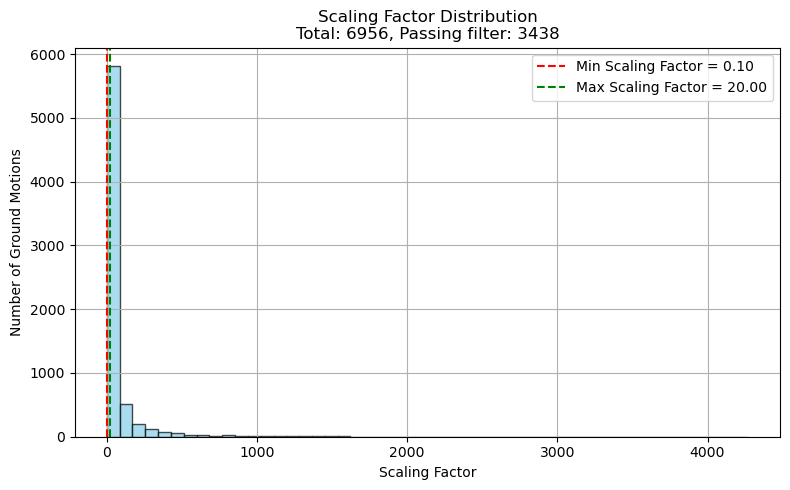

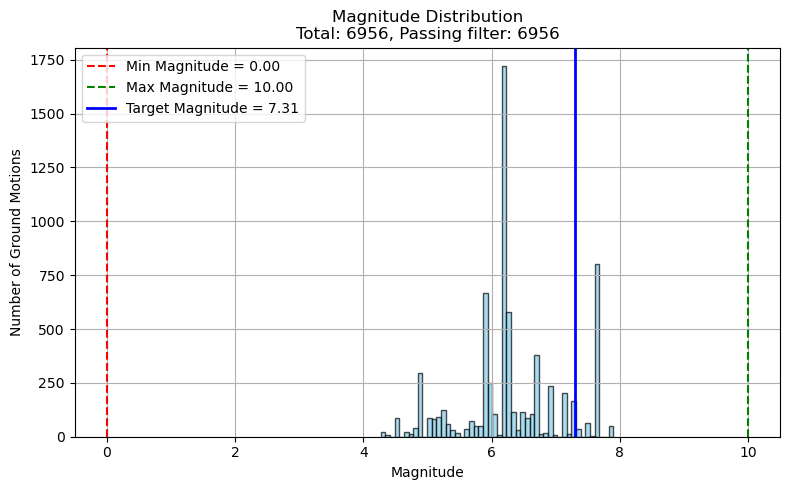

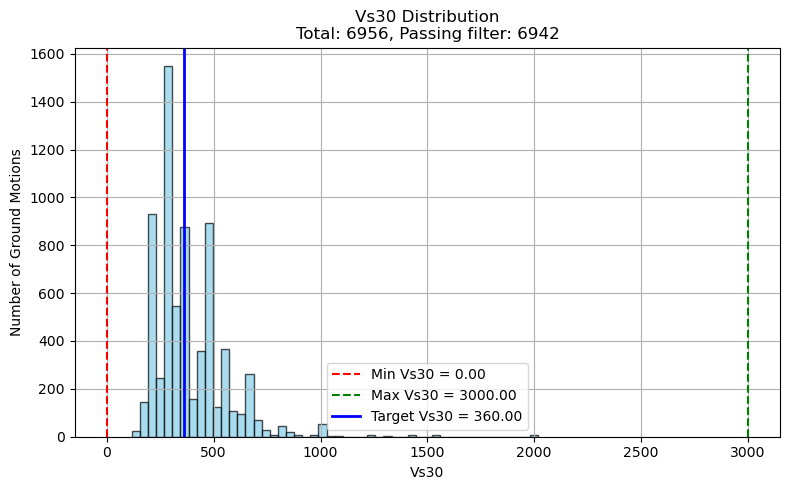

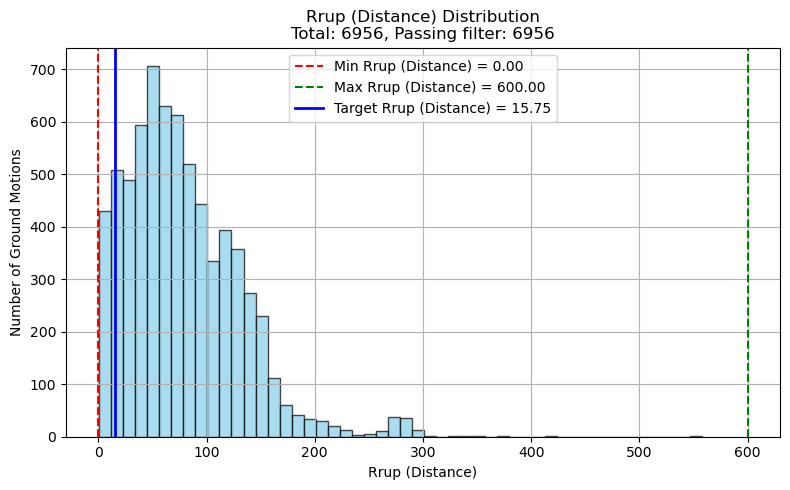

Total initial samples: 6956
Filtering summary:
After scaling filter: 3438
After magnitude filter: 3438
After Vs30 filter: 3437
After distance filter: 3437
Final accepted samples: 3437
GroundMotionSelection.optimize_selection: current total error: 0.082458.
GroundMotionSelection.optimize_selection: 10.00%.
GroundMotionSelection.optimize_selection: current total error: 0.011489.
GroundMotionSelection.optimize_selection: 20.00%.
GroundMotionSelection.optimize_selection: current total error: 0.007359.
GroundMotionSelection.optimize_selection: 30.00%.
GroundMotionSelection.optimize_selection: current total error: 0.005480.
GroundMotionSelection.optimize_selection: 40.00%.
GroundMotionSelection.optimize_selection: current total error: 0.005480.
GroundMotionSelection.optimize_selection: 50.00%.
GroundMotionSelection.optimize_selection: current total error: 0.003287.
GroundMotionSelection.optimize_selection: 60.00%.
GroundMotionSelection.optimize_selection: current total error: 0.003287.
Groun

Timer unit: 1e-07 s

Total time: 3.79346 s
File: c:\Users\Marguerite\OneDrive\Documents\stanford\Ground Motion Selection\pygms\commit1\pygms.py
Function: optimize_selection at line 396

Line #      Hits         Time  Per Hit   % Time  Line Contents
   396                                               def optimize_selection(self, ims, num_greedy_rounds=2):
   397                                                   """
   398                                                   Greedy algorithm search to minimize the combined error
   399                                                   (fast version, unsafe updates, optimized for performance)
   400                                           
   401                                                   Changes vs optimize_selection2:
   402                                                   - Precomputes gmdb_subset and target std once (avoids repeated slicing and diag calls)
   403                                                   - Precomputes 

In [ ]:
# ground motion selection
gms_config = job_config.get('GroundMotionSelection')
gms_config.update({'TargetType':tgt_config.get('TargetType')})
gms_config['Hazard']=tgt_config.get('Hazard')

my_gms = GroundMotionSelection(gms_config)
my_gms.generate_pseudo_im(my_tgt.im_target)
my_gms.initial_scanning(my_tgt.ims,my_tgt.cond_imv,my_tgt.cond_im_idx)
my_gms.optimize_selection(my_tgt.ims)

my_gms.export_selection(my_tgt.ims)

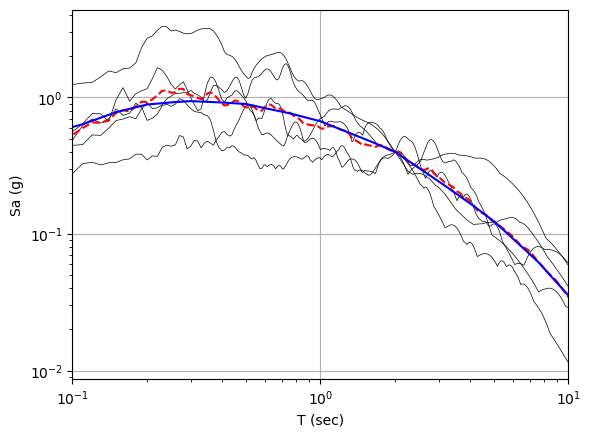

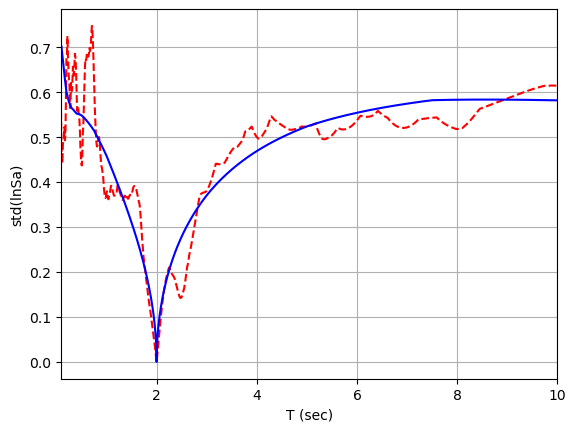

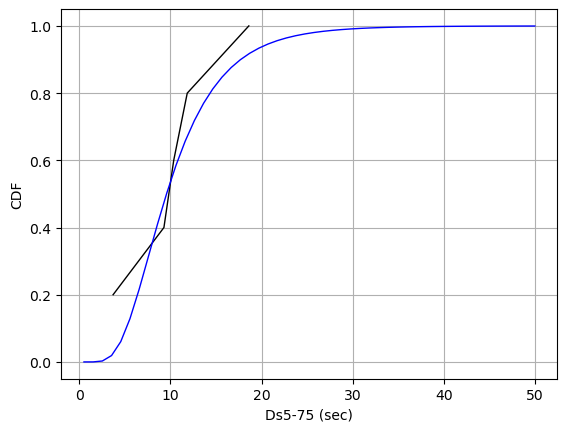

In [15]:
# plot
plt.loglog(my_gms.selection_periods, np.exp(my_gms.gmdb_imv[np.ix_(my_gms.selected_id,my_gms.ims_idx[0:len(my_gms.selection_periods)])]).T,color='k',linewidth=0.5)
plt.loglog(my_gms.selection_periods, np.exp(np.mean(my_gms.gmdb_imv[np.ix_(my_gms.selected_id,my_gms.ims_idx[0:len(my_gms.selection_periods)])],axis=0)).T,color='r',linestyle='--')
plt.loglog(my_gms.selection_periods, np.exp(my_gms.tgt_mean[0:len(my_gms.selection_periods)]),color='b',linestyle='-')
# Add labels and title
plt.xlabel('T (sec)')
plt.ylabel('Sa (g)')
plt.xlim([0.1,10])
plt.grid()
# Show plot
plt.show()

if my_gms.tgt_type in ['CSD','CS']:
    plt.plot(my_gms.selection_periods, np.std(my_gms.gmdb_imv[np.ix_(my_gms.selected_id,my_gms.ims_idx[0:len(my_gms.selection_periods)])],axis=0),color='r',linestyle='--')
    plt.plot(my_gms.selection_periods, np.sqrt(np.diag(my_gms.tgt_cov))[0:len(my_gms.selection_periods)],color='b',linestyle='-')
    # Add labels and title
    plt.xlabel('T (sec)')
    plt.ylabel('std(lnSa)')
    plt.xlim([0.1,10])
    plt.grid()
    # Show plot
    plt.show()

if my_gms.tgt_type in ['CSD']:
    x = np.sort(np.exp(my_gms.gmdb_imv[my_gms.selected_id,-1]))
    y = np.arange(1,my_gms.num_rec+1)/my_gms.num_rec
    plt.plot(x, y,color='k',linewidth=1)
    x = np.linspace(0.5,50,50)
    y = norm.cdf(np.log(x), loc=my_gms.tgt_mean[-1], scale=np.sqrt(np.diag(my_gms.tgt_cov))[-1])
    plt.plot(x, y,color='b',linewidth=1)
    # Add labels and title
    plt.xlabel('Ds5-75 (sec)')
    plt.ylabel('CDF')
    plt.grid()
    # Show plot
    plt.show()